In [19]:
import pandas as pd
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree 
import matplotlib.pyplot as plt

In [20]:
df = pd.read_excel("loan_eligibility_dataset.xlsx")

In [21]:
df.dtypes

Applicant_ID            str
Gender                  str
Married                 str
Dependents              str
Education               str
Self_Employed           str
Applicant_Income      int64
Coapplicant_Income    int64
Loan_Amount           int64
Credit_History        int64
Property_Area           str
Loan_Status             str
dtype: object

In [22]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20 entries, 0 to 19
Data columns (total 12 columns):
 #   Column              Non-Null Count  Dtype
---  ------              --------------  -----
 0   Applicant_ID        20 non-null     str  
 1   Gender              20 non-null     str  
 2   Married             20 non-null     str  
 3   Dependents          20 non-null     str  
 4   Education           20 non-null     str  
 5   Self_Employed       20 non-null     str  
 6   Applicant_Income    20 non-null     int64
 7   Coapplicant_Income  20 non-null     int64
 8   Loan_Amount         20 non-null     int64
 9   Credit_History      20 non-null     int64
 10  Property_Area       20 non-null     str  
 11  Loan_Status         20 non-null     str  
dtypes: int64(4), str(8)
memory usage: 2.0 KB


In [23]:
df.describe()

,Applicant_Income,Coapplicant_Income,Loan_Amount,Credit_History
count,20.000000,20.000000,20.000000,20.000000
mean,39150.000000,7900.000000,183500.000000,0.600000
std,13546.314317,6381.717307,64422.536103,0.502625
min,22000.000000,0.000000,100000.000000,0.000000
25%,27750.000000,3750.000000,145000.000000,0.000000
50%,36500.000000,7500.000000,180000.000000,1.000000
75%,48500.000000,12000.000000,205000.000000,1.000000
max,70000.000000,20000.000000,350000.000000,1.000000


In [24]:
df.isnull()

,Applicant_ID,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Credit_History,Property_Area,Loan_Status
0,False,False,False,False,False,False,False,False,False,False,False,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,False,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,False,False
5,False,False,False,False,False,False,False,False,False,False,False,False
6,False,False,False,False,False,False,False,False,False,False,False,False
7,False,False,False,False,False,False,False,False,False,False,False,False
8,False,False,False,False,False,False,False,False,False,False,False,False
9,False,False,False,False,False,False,False,False,False,False,False,False


In [25]:
df["Dependents"] = df["Dependents"].replace("3+", "3")

df = df.drop(columns=["Applicant_ID"], errors="ignore")

for column in df.columns:

    if df[column].dtype in ["object", "string"]:
        df[column] = df[column].fillna(df[column].mode()[0])
    else:
        df[column] = df[column].fillna(df[column].median())
        
encoders = {}

for column in df.select_dtypes(include=["object","string"]).columns:
    encoder = LabelEncoder()
    df[column] = encoder.fit_transform(df[column]) 
    encoders[column] = encoder

df

,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Credit_History,Property_Area,Loan_Status
0,1,1,0,0,0,50000,20000,200000,1,2,1
1,0,0,0,0,0,35000,0,150000,1,2,1
2,1,1,1,0,1,30000,10000,180000,0,0,0
3,1,0,0,1,0,25000,5000,100000,1,1,1
4,0,1,2,0,0,45000,15000,250000,1,2,1
5,1,1,3,1,1,28000,8000,200000,0,0,0
6,0,0,0,0,0,60000,0,300000,1,2,1
7,1,1,1,0,0,32000,12000,150000,0,0,0
8,1,0,0,0,0,55000,5000,180000,1,1,1
9,0,1,2,1,0,27000,10000,120000,0,0,0


In [26]:
df.shape

(20, 11)

In [27]:
x = df.drop("Loan_Status", axis=1)
x

,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Credit_History,Property_Area
0,1,1,0,0,0,50000,20000,200000,1,2
1,0,0,0,0,0,35000,0,150000,1,2
2,1,1,1,0,1,30000,10000,180000,0,0
3,1,0,0,1,0,25000,5000,100000,1,1
4,0,1,2,0,0,45000,15000,250000,1,2
5,1,1,3,1,1,28000,8000,200000,0,0
6,0,0,0,0,0,60000,0,300000,1,2
7,1,1,1,0,0,32000,12000,150000,0,0
8,1,0,0,0,0,55000,5000,180000,1,1
9,0,1,2,1,0,27000,10000,120000,0,0


In [28]:
y = df[["Loan_Status"]]
y

,Loan_Status
0,1
1,1
2,0
3,1
4,1
5,0
6,1
7,0
8,1
9,0


In [29]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(x, y, test_size=0.2, random_state=42)

In [30]:
Xtrain

,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Credit_History,Property_Area
8,1,0,0,0,0,55000,5000,180000,1,1
5,1,1,3,1,1,28000,8000,200000,0,0
11,0,0,1,0,1,40000,5000,200000,1,1
3,1,0,0,1,0,25000,5000,100000,1,1
18,0,1,2,0,0,46000,14000,230000,1,1
16,0,0,0,0,0,38000,0,160000,1,2
13,0,1,0,0,0,48000,12000,180000,1,2
2,1,1,1,0,1,30000,10000,180000,0,0
9,0,1,2,1,0,27000,10000,120000,0,0
19,1,0,0,0,0,30000,0,130000,0,0


In [31]:
Xtest

,Gender,Married,Dependents,Education,Self_Employed,Applicant_Income,Coapplicant_Income,Loan_Amount,Credit_History,Property_Area
0,1,1,0,0,0,50000,20000,200000,1,2
17,1,1,3,1,1,24000,7000,150000,0,0
15,1,1,1,0,0,52000,10000,220000,1,1
1,0,0,0,0,0,35000,0,150000,1,2


In [32]:
Ytrain

,Loan_Status
8,1
5,0
11,1
3,1
18,1
16,1
13,1
2,0
9,0
19,0


In [33]:
Ytest

,Loan_Status
0,1
17,0
15,1
1,1


In [34]:
model = DecisionTreeClassifier(criterion='gini', max_depth=3)
model.fit(Xtrain, Ytrain)

,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",3
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.",'gini'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split among considered features for this split.",'best'
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: splitting may inspect more than ``max_features`` features ifneeded to find a valid split.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary <random_state>` for details.",None
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow a tree with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples 

In [35]:
y_pred = model.predict(Xtest)
y_pred

array([1, 0, 1, 1])

In [36]:
Ytest

,Loan_Status
0,1
17,0
15,1
1,1


In [37]:
print("Accuracy", accuracy_score(Ytest, y_pred)*100)

Accuracy 100.0


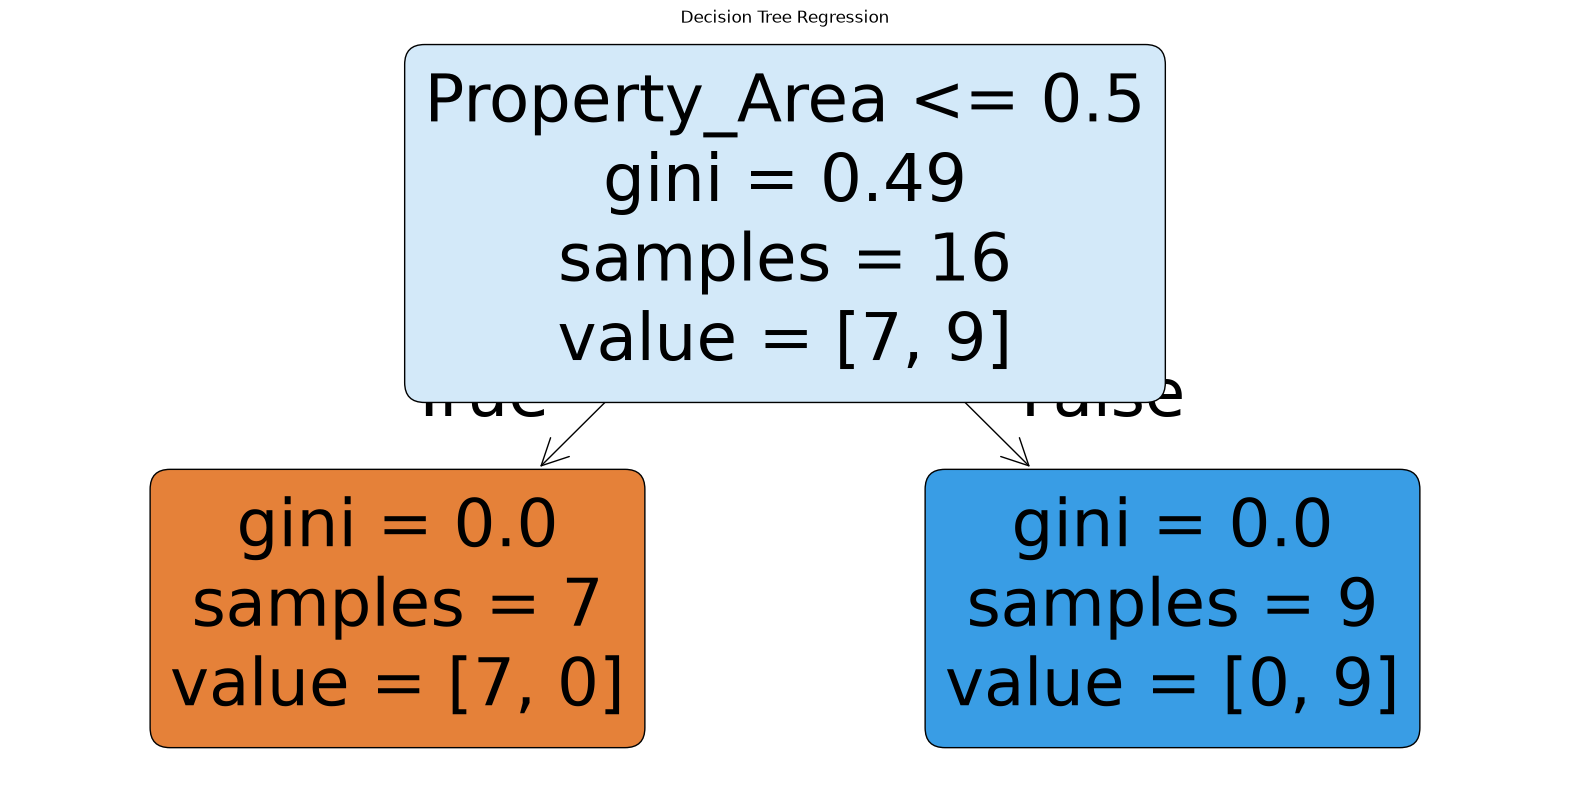

In [38]:
plt.figure(figsize=(20, 10))

plot_tree(model, feature_names=x.columns, filled=True, rounded=True, precision=2)

plt.title("Decision Tree Regression")

plt.show()